In [1]:
import pandas as pd
import numpy as np

Données de : https://www.cryptoarchive.com.au/

In [2]:
cols = ["timestamp", "open", "high", "low", "close", "volume", "close_time", "quote_asset_volume", "trades", "ignore"]
df = pd.read_csv("BTCUSDT.csv", sep="|", header=None, names=cols, usecols=["timestamp", "open", "high", "low", "close", "volume"])

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
df = df.set_index("timestamp")

In [3]:
df

,open,high,low,close,volume
timestamp,,,,,
2017-08-17 04:00:00,4261.48,4261.48,4261.48,4261.48,1.775183
2017-08-17 04:01:00,4261.48,4261.48,4261.48,4261.48,0.000000
2017-08-17 04:02:00,4280.56,4280.56,4280.56,4280.56,0.261074
2017-08-17 04:03:00,4261.48,4261.48,4261.48,4261.48,0.012008
2017-08-17 04:04:00,4261.48,4261.48,4261.48,4261.48,0.140796
...,...,...,...,...,...
2026-04-21 15:42:00,75676.99,75712.00,75657.89,75712.00,7.672540
2026-04-21 15:43:00,75712.66,75746.47,75712.66,75732.47,5.510390
2026-04-21 15:44:00,75732.48,75763.03,75701.50,75701.50,5.428980


Ici, build_dataset prend en entrée les données brutes OHLCV, un horizon de candles et un quantile pour un seuil adaptif (seuil sur fenêtre glissante de 24h). Donc un horizon est volatile si il est dans le top percentile% des plus volatile de la journée. On construit plusieurs features pour la volatilité, ensuite on génère la cible binaire qui indique si oui ou non la volatilité sur le prochain horizon est plus volatile que d'habitude (basé sur le percentile fourni). Donc y=0 pas d'instabilité, y=1 instabilité (peu importe le sens). La cible se base sur l'écart-type du log-return (ratio log(p_t/p_t-1)). Donc si 120 candles d'horizon (1 candles = 1m ici, donc 2h) on regarde l'écart-type du prochain horizon des log-returns pour déterminer la cible. Puisque le seuil est dynamique, car les régimes et échelles des prix changent dans le temps (surtout avec BTC) on ordonne les volatilités futures trouvées, puis on choisit un seuil basé sur le percentile fourni. On peut utiliser build_dataset pour l'entrainnement et la prédiction (target_only=True). Ajout du stride pour pouvoir garder seulement 1 candles sur stride : ca permet de réduire la taille du jeu de données et la redondance de sans perdre trop d'information. Donc stride=60 donne des sous-échantillons à chaque 60 minutes par exemple.

In [4]:
def build_dataset(raw_df: pd.DataFrame, candles_window: int, stride: int, quantile_thr: float, target_only=False) -> tuple[pd.DataFrame, pd.Series | None]:
    eps = 1e-8
    idx = raw_df.index

    close = raw_df["close"].astype("float64")
    high = raw_df["high"].astype("float64")
    low = raw_df["low"].astype("float64")
    open_ = raw_df["open"].astype("float64")

    log_close = np.log(close)
    log_open = np.log(open_)
    log_high = np.log(high)
    log_low = np.log(low)

    log_ret = log_close.diff()
    abs_ret = log_ret.abs()
    hl = log_high - log_low
    log_co = log_close - log_open

    half_window = max(2, candles_window // 2)
    double_window = candles_window * 2
    regime_window = max(100, candles_window * 10)

    vol_w = log_ret.rolling(candles_window).std().rename("vol")
    vol_half = log_ret.rolling(half_window).std().rename(f"vol_{half_window}")
    vol_double = log_ret.rolling(double_window).std().rename(f"vol_{double_window}")

    absret_w = abs_ret.rolling(candles_window).mean().rename("absret")
    absret_half = abs_ret.rolling(half_window).mean().rename(f"absret_{half_window}")
    absret_double = abs_ret.rolling(double_window).mean().rename(f"absret_{double_window}")

    momentum_w = close.pct_change(candles_window).rename("momentum")
    trend_strength_10 = close.pct_change(10).abs().rename("trend_strength")
    range_w = (((high - low) / close).rolling(candles_window).mean()).rename("range")

    gk_var = 0.5 * hl.pow(2) - (2 * np.log(2) - 1) * log_co.pow(2)
    gk = gk_var.rolling(candles_window).mean().clip(lower=0).pow(0.5).rename("gk")

    parkinson_var = hl.pow(2) / (4 * np.log(2))
    parkinson = parkinson_var.rolling(candles_window).mean().clip(lower=0).pow(0.5).rename("parkinson")

    rs_var = (log_high - log_close) * (log_high - log_open) + (log_low - log_close) * (log_low - log_open)
    rogers_satchell = rs_var.rolling(candles_window).mean().clip(lower=0).pow(0.5).rename("rogers_satchell")

    volvol = vol_w.rolling(candles_window).std().rename("volvol")
    vol_ratio = (vol_half / (vol_double + eps)).rename("vol_ratio")
    vol_diff = (vol_half - vol_double).rename("vol_diff")

    skew = log_ret.rolling(candles_window).skew().rename("skew")
    kurt = log_ret.rolling(candles_window).kurt().rename("kurt")

    neg_ret = log_ret.where(log_ret < 0, 0.0)
    pos_ret = log_ret.where(log_ret > 0, 0.0)
    down_vol = neg_ret.rolling(candles_window).std().rename("down_vol")
    up_vol = pos_ret.rolling(candles_window).std().rename("up_vol")
    vol_ratio_ud = (up_vol / (down_vol + eps)).rename("vol_ratio_ud")

    ema_fast = close.ewm(span=12, adjust=False).mean()
    ema_slow = close.ewm(span=26, adjust=False).mean()
    ema_diff = ((ema_fast - ema_slow) / close).rename("ema_diff")

    candle_body = ((close - open_) / close).rename("candle_body")
    upper_wick = ((high - np.maximum(close, open_)) / close).rename("upper_wick")
    lower_wick = ((np.minimum(close, open_) - low) / close).rename("lower_wick")

    rolling_vol = vol_w
    vol_mean = rolling_vol.rolling(regime_window).mean()
    vol_std = rolling_vol.rolling(regime_window).std()
    vol_zscore = ((rolling_vol - vol_mean) / (vol_std + eps)).rename("vol_zscore")
    high_vol_regime = (vol_zscore > 1.0).astype("float64").rename("high_vol_regime")

    autocorr_cols = [log_ret.rolling(candles_window).corr(log_ret.shift(lag)).rename(f"autocorr_{lag}") for lag in (1,2,3,5)]
    lag_cols = [vol_w.shift(lag).rename(f"vol_lag_{lag}") for lag in (1,2,3,5,10)] + [log_ret.shift(lag).rename(f"log_ret_lag_{lag}")
                                                                                      for lag in (1,2,3,5,10)]

    X = pd.concat([log_ret.rename("log_ret"),vol_w,absret_w,momentum_w,range_w,gk,parkinson,rogers_satchell,volvol,vol_half,vol_double,absret_half,absret_double,vol_ratio,vol_diff,skew,kurt,down_vol,up_vol,vol_ratio_ud,ema_diff,trend_strength_10,candle_body,upper_wick,lower_wick,vol_zscore,high_vol_regime,*lag_cols,*autocorr_cols], axis=1).reindex(idx)

    rolling_mean = X.rolling(candles_window).mean()
    rolling_std = X.rolling(candles_window).std()
    X = (X - rolling_mean) / (rolling_std + eps)

    if not target_only:
        future_vol = log_ret.rolling(candles_window).std().shift(-candles_window)
        thr = future_vol.rolling(24 * 60).quantile(quantile_thr)
        y = (future_vol >= thr).astype(int).rename("volatility")

        valid_idx = X.notna().all(axis=1) & y.notna()
        X = X.loc[valid_idx]
        y = y.loc[valid_idx]
    else:
        y = None
        valid_idx = X.notna().all(axis=1)
        X = X.loc[valid_idx]

    X = X.iloc[::stride]
    if y is not None:
        y = y.iloc[::stride]

    return X, y

Ici on a l'horizon qui regarde les prochains 120 minutes, on sous-échantillones à chaque 60 minutes et on étiquette les observations à volatile (y=1) si leur volatilité future appartient au 10% plus volatile localement (sur une fenêtre glissante de 24h).

In [5]:
WINDOW = 120
STRIDE = WINDOW // 2
PERCENTILE = .9

X, y = build_dataset(df, WINDOW, STRIDE, PERCENTILE)

Toutes les variables dans X sont normalisées :

In [6]:
X

,log_ret,vol,absret,momentum,range,gk,parkinson,rogers_satchell,volvol,vol_60,...,vol_lag_10,log_ret_lag_1,log_ret_lag_2,log_ret_lag_3,log_ret_lag_5,log_ret_lag_10,autocorr_1,autocorr_2,autocorr_3,autocorr_5
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-08-18 03:58:00,-0.931602,-1.272196,-1.337860,0.568077,-0.873095,-1.110678,-0.997124,-1.138734,-0.510931,0.858080,...,-1.240260,-0.017452,-0.014969,-0.014969,-0.025736,1.706906,0.128034,0.510198,-1.084023,-0.383245
2017-08-18 04:58:00,-0.015078,0.457704,0.748951,-0.125936,0.104868,-0.355698,-0.016664,-0.590653,-1.522782,-0.974956,...,0.514022,-0.015078,-0.015078,-0.015078,0.137010,-0.012479,0.759835,-1.596021,-0.249539,0.820911
2017-08-18 05:58:00,-0.028608,2.055336,1.228099,0.973474,2.764907,2.526175,2.768792,2.139366,-0.214797,2.887311,...,0.410322,-0.358477,-0.025065,2.977885,-3.122615,0.432432,-0.699210,-1.281133,2.721350,-0.318029
2017-08-18 06:58:00,-1.774173,1.633106,1.902036,-1.327249,1.766245,1.510601,1.556968,1.446399,2.084249,0.072036,...,1.869053,1.162666,-0.000068,-0.000068,-0.000068,-0.002656,-0.931820,0.257359,0.282811,2.265664
2017-08-18 07:58:00,-1.919752,-2.674855,-2.262170,-1.515068,-2.302871,-2.457018,-2.499608,-2.295381,-0.919222,-2.495753,...,-1.510089,1.003615,-0.967693,0.015438,-0.013165,-0.007288,-1.485230,3.051839,-3.345773,2.416007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-21 11:39:00,0.541380,-0.582438,-0.221379,1.034170,-0.801399,-1.146337,-0.964399,-1.256768,0.984462,1.255352,...,-0.799130,-0.649344,-0.771677,1.771592,-2.382454,0.283192,1.103608,0.131991,0.939001,-2.510291
2026-04-21 12:39:00,-3.838556,2.371153,3.427260,-2.559032,4.183857,1.603118,2.122207,1.207457,-1.228910,1.947755,...,0.372165,-2.571583,-2.344791,0.919696,1.517729,0.382405,0.332625,2.319184,-0.370326,-2.557948
2026-04-21 13:39:00,-1.157957,0.729499,0.707299,-1.307479,1.445517,1.682232,1.303695,1.996446,0.700698,0.028002,...,0.818153,0.346069,-0.660730,0.077696,0.540607,-0.007743,-1.615694,1.234980,-1.655208,1.398837


---
## Visualisation de la cible et du jeu de données brute

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_candles_targets(df, y, start_date, end_date, window, stride):
    s, e = pd.to_datetime(start_date), pd.to_datetime(end_date)

    d = df.loc[s:e, ["open", "high", "low", "close"]].astype(float)
    if d.empty:
        raise ValueError("Empty slice")

    g0 = df.index.get_loc(d.index[0])
    g1 = df.index.get_loc(d.index[-1])
    pos = np.arange(g0, g1 + 1)
    x = pos - g0

    fig, ax = plt.subplots(figsize=(16, 7))
    w = 0.6

    for xi, (_, row) in zip(x, d.iterrows()):
        o, h, l, c = row["open"], row["high"], row["low"], row["close"]
        col = "green" if c >= o else "red"
        ax.vlines(xi, l, h, color=col, lw=1)
        ax.add_patch(Rectangle((xi - w / 2, min(o, c)), w, max(abs(c - o), 1e-12), fc=col, ec=col, lw=0.8))

    first_y = df.index.get_loc(y.index[0])
    for p in range(first_y, len(df), stride):
        if g0 <= p <= g1:
            ax.axvline(p - g0, color="gray", ls="--", lw=1, alpha=0.35)

    pos_y1 = df.index.get_indexer(y[y.eq(1)].index)
    pos_y1 = pos_y1[pos_y1 >= 0]

    for p in pos_y1:
        a, b = p, p + window
        if b < g0 or a > g1:
            continue
        ax.axvspan(max(a, g0) - g0, min(b, g1) - g0, color="red", alpha=0.15)

    plt.title(f"Visualisation des candles et des zones volatiles pour la période {start_date} - {end_date}")
    plt.xlabel("Index candle")
    plt.ylabel("Prix (USD)")

    ax.set_xlim(0, len(d) - 1)
    ax.grid(alpha=0.2)
    plt.show()

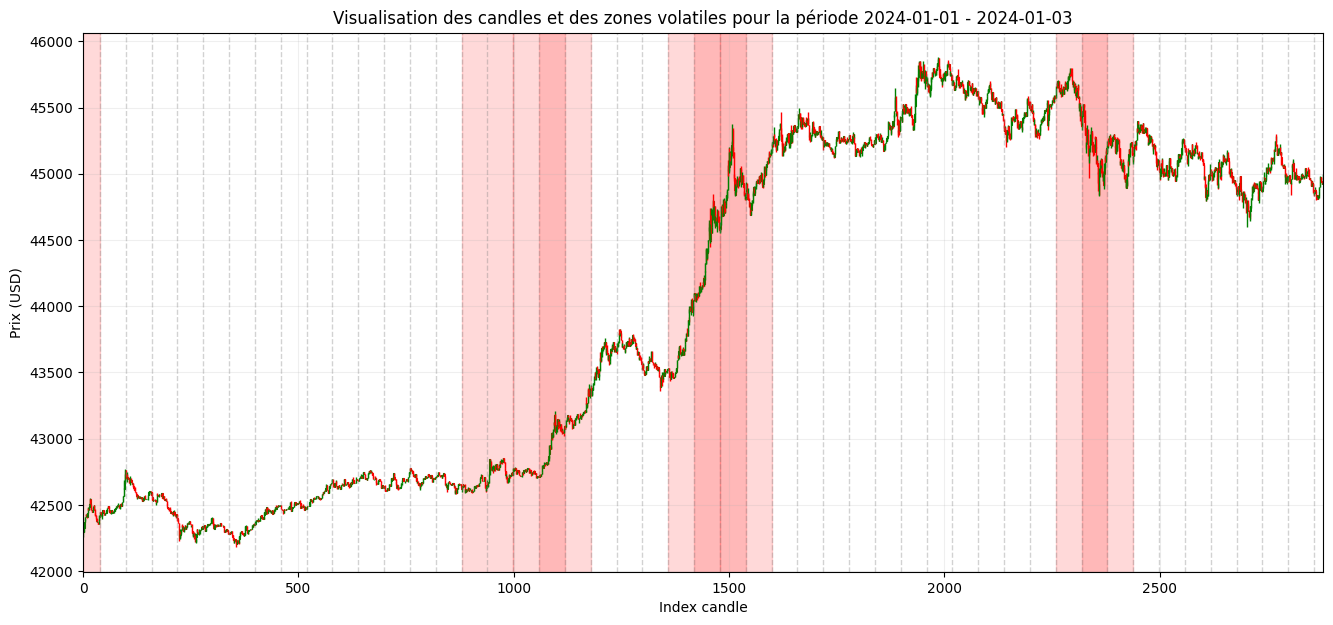

In [8]:
plot_candles_targets(df, y, start_date="2024-01-01", end_date="2024-01-03", window=WINDOW, stride=STRIDE)

Le graphe ci-haut est une représentation de la cible : les lignes verticales grises sont les strides (ou le sous-échantillonage de 60 minutes), en rouge on a les moments de volatilité (pas les cibles mais bien la volatilité détectée donc décalage de WINDOW entre échantillon X et cible y [pour que ca soit plus facile à comprendre graphiquement]).

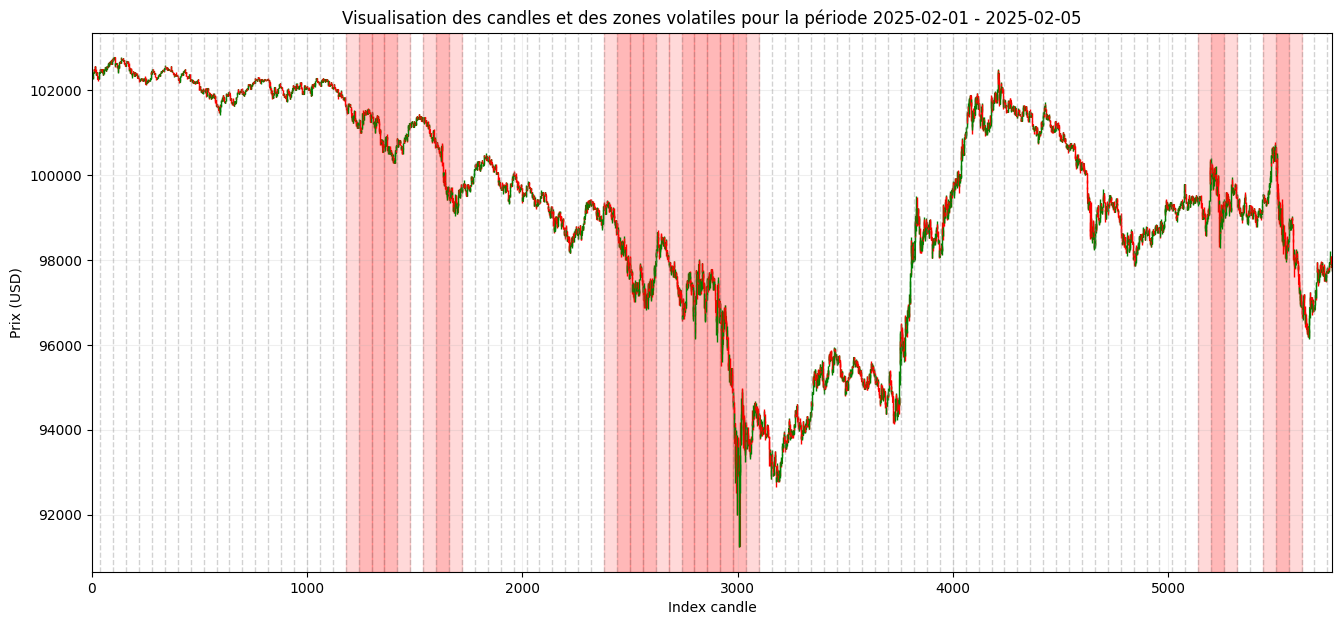

In [9]:
plot_candles_targets(df, y, start_date="2025-02-01", end_date="2025-02-05", window=WINDOW, stride=STRIDE)

L'exemple ici montre la faiblesse/limite de notre cible, on voit un gros "spike" positif (entre 3500 et 4000) pourtant on le considère pas comme cible : très probablement à cause que c'est une croissance plus progressive et moins variable. Notre cible mesure la dispersion (écart type) du log return, pas l'amplitude. Aussi, le percentile 90 a un gros impact ici aussi : puisqu'il y a des gros spikes autour de la monté positive, sa variance est relativement moins importante donc on ne la considère pas comme une zone volatile dans notre cas.

---
## Apprentissage et évaluation de modèles

In [10]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, average_precision_score, precision_recall_curve

def evaluate_timeseries_cv_proba(titre, all_y_true, all_y_proba, top_k=0.1):
    print(f"=== Évaluation de {titre} ===")
    y_true = np.concatenate([np.asarray(y).astype(int) for y in all_y_true])
    y_proba = np.concatenate([np.asarray(p, dtype=float) for p in all_y_proba])

    if y_true.shape[0] != y_proba.shape[0]:
        raise ValueError("y_true and y_proba must have the same length")
    if not (0 < top_k < 1):
        raise ValueError("k_frac must be in (0, 1)")

    threshold = np.quantile(y_proba, 1 - top_k)
    y_pred = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    im = axes[0].imshow(cm, cmap="Blues")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title(f"Confusion Matrix (top {int(top_k * 100)}%)")

    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j],
                         ha="center", va="center", color="grey")

    plt.colorbar(im, ax=axes[0])

    axes[1].plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    print(f"n_samples          : {len(y_true)}")
    print(f"top_k_frac         : {top_k:.2f}")
    print(f"threshold          : {threshold:.4f}")
    print(f"precision          : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"recall             : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"pr_auc             : {pr_auc:.4f}")
    print(f"P(y=1) [Baseline]  : {np.mean(all_y_true):.4f}")

In [11]:
from sklearn.model_selection import TimeSeriesSplit

def trainAndEvaluate(titre, X, y, model_class, train_on_all_data=False, top_k=0.01, **kwargs):
    all_y_true = []
    all_y_proba = []

    tscv = TimeSeriesSplit(n_splits=5)

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = model_class(**kwargs)
        model.fit(X_train, y_train)

        proba = model.predict_proba(X_test)[:, 1]

        all_y_true.append(y_test.values)
        all_y_proba.append(proba)

    evaluate_timeseries_cv_proba(titre, all_y_true, all_y_proba, top_k=top_k)

    if train_on_all_data:
        model = model_class(**kwargs)
        model.fit(X, y)

        return model

    return None

### GBM - sklearn

=== Évaluation de GBM - SKlearn ===


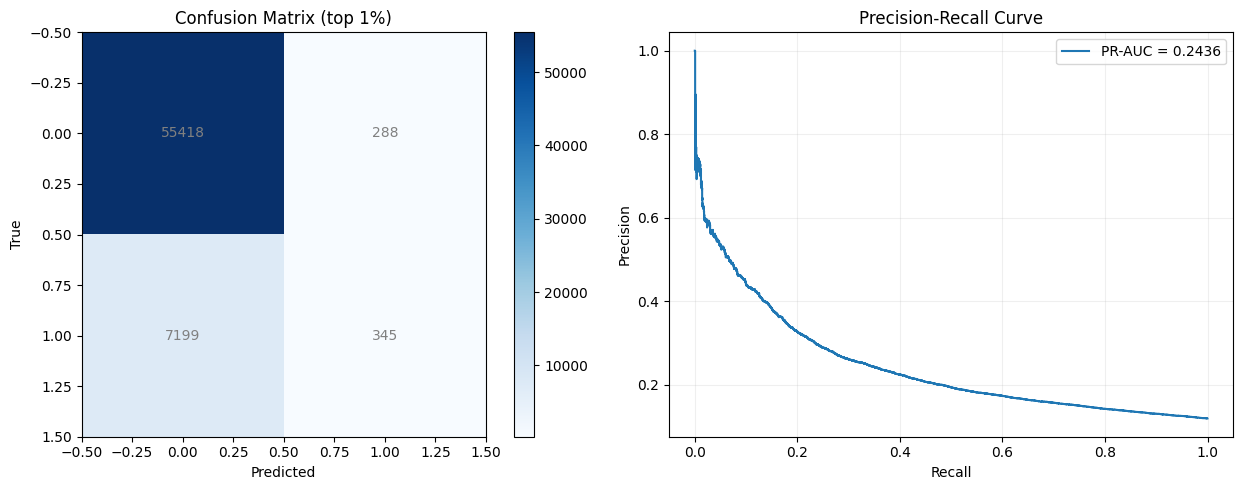

n_samples          : 63250
top_k_frac         : 0.01
threshold          : 0.7937
precision          : 0.5450
recall             : 0.0457
pr_auc             : 0.2436
P(y=1) [Baseline]  : 0.1193


In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier

trainAndEvaluate("GBM - SKlearn", X, y, HistGradientBoostingClassifier, top_k=0.01, class_weight="balanced", random_state=42)

### GBM LightGBM

=== Évaluation de GBM - LightGBM ===


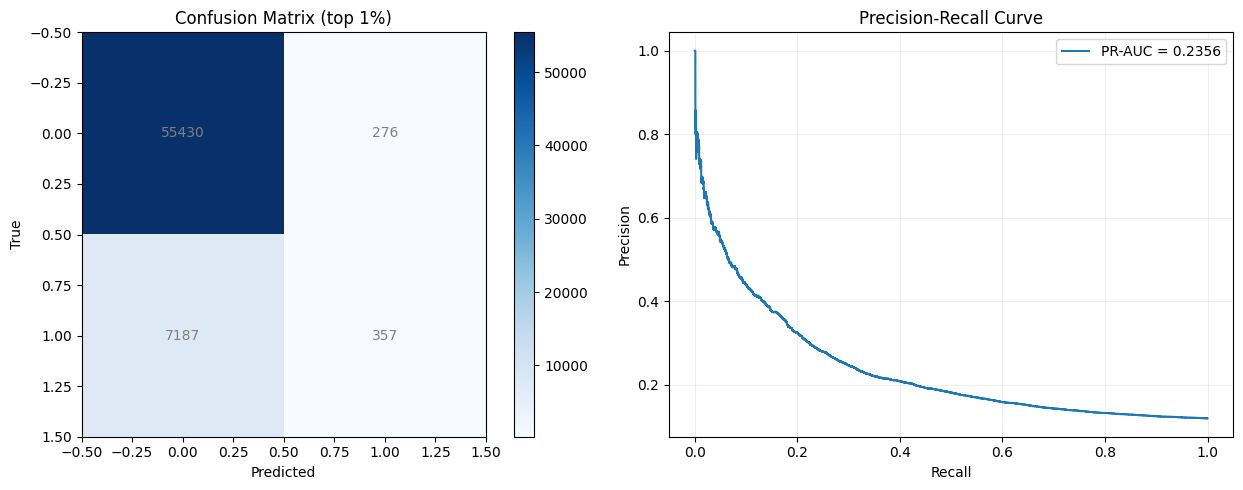

n_samples          : 63250
top_k_frac         : 0.01
threshold          : 0.7823
precision          : 0.5640
recall             : 0.0473
pr_auc             : 0.2356
P(y=1) [Baseline]  : 0.1193


In [13]:
from lightgbm import LGBMClassifier

lgbm = trainAndEvaluate("GBM - LightGBM", X, y, LGBMClassifier, train_on_all_data=True, top_k=0.01, objective="binary",
                        class_weight="balanced", n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)

### Forêt Aléatoire

=== Évaluation de Forêt Aléatoire - SKlearn ===


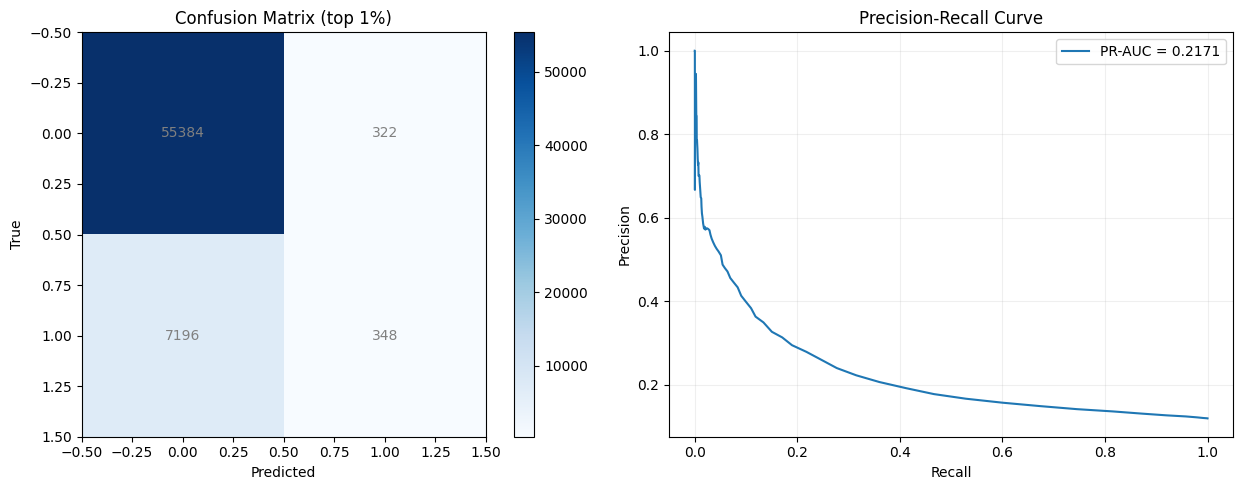

n_samples          : 63250
top_k_frac         : 0.01
threshold          : 0.3500
precision          : 0.5194
recall             : 0.0461
pr_auc             : 0.2171
P(y=1) [Baseline]  : 0.1193


In [14]:
from sklearn.ensemble import RandomForestClassifier

trainAndEvaluate("Forêt Aléatoire - SKlearn", X, y, RandomForestClassifier, top_k=0.01, class_weight="balanced", random_state=42)

=== Évaluation de KNN - SKlearn ===


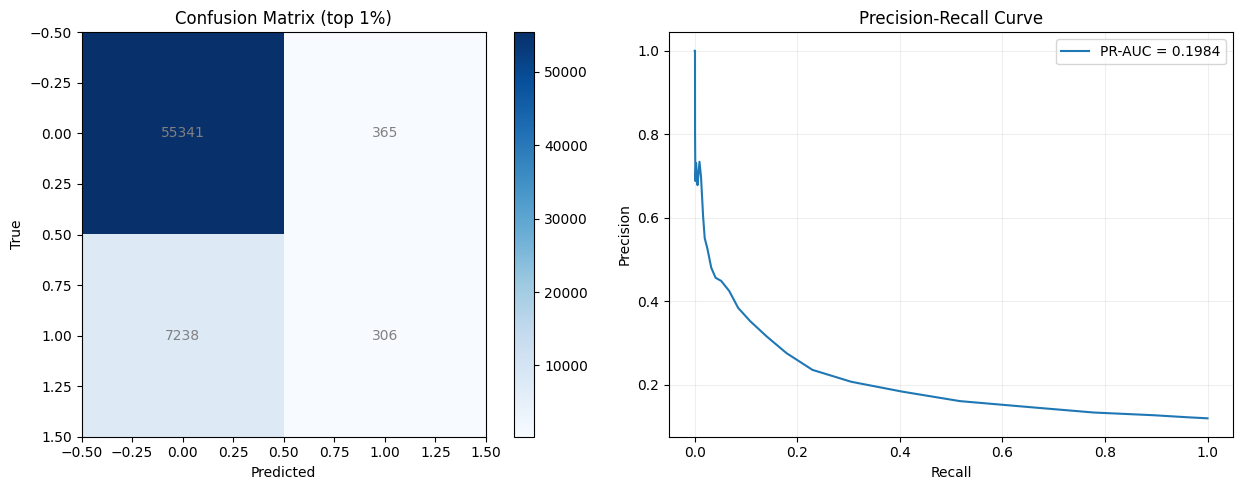

n_samples          : 63250
top_k_frac         : 0.01
threshold          : 0.3137
precision          : 0.4560
recall             : 0.0406
pr_auc             : 0.1984
P(y=1) [Baseline]  : 0.1193


In [15]:
from sklearn.neighbors import KNeighborsClassifier

trainAndEvaluate("KNN - SKlearn", X, y, KNeighborsClassifier, top_k=0.01, n_neighbors=51)

---
### Performance sur un autre jeu de données : SOL/USDT

In [16]:
def loadCryptoCSV(filepath: str):
    cols = ["timestamp", "open", "high", "low", "close", "volume", "close_time", "quote_asset_volume", "trades", "ignore"]
    new_df = pd.read_csv(filepath, sep="|", header=None, names=cols, usecols=["timestamp", "open", "high", "low", "close", "volume"])

    new_df["timestamp"] = pd.to_datetime(new_df["timestamp"], unit="s")
    new_df = new_df.set_index("timestamp")

    return new_df

In [17]:
sol_df = loadCryptoCSV("SOLUSDT.csv")
X_sol, y_sol = build_dataset(sol_df, WINDOW, STRIDE, PERCENTILE)

=== Évaluation de GBM lightgbm entrainné sur BTC pour SOL ===


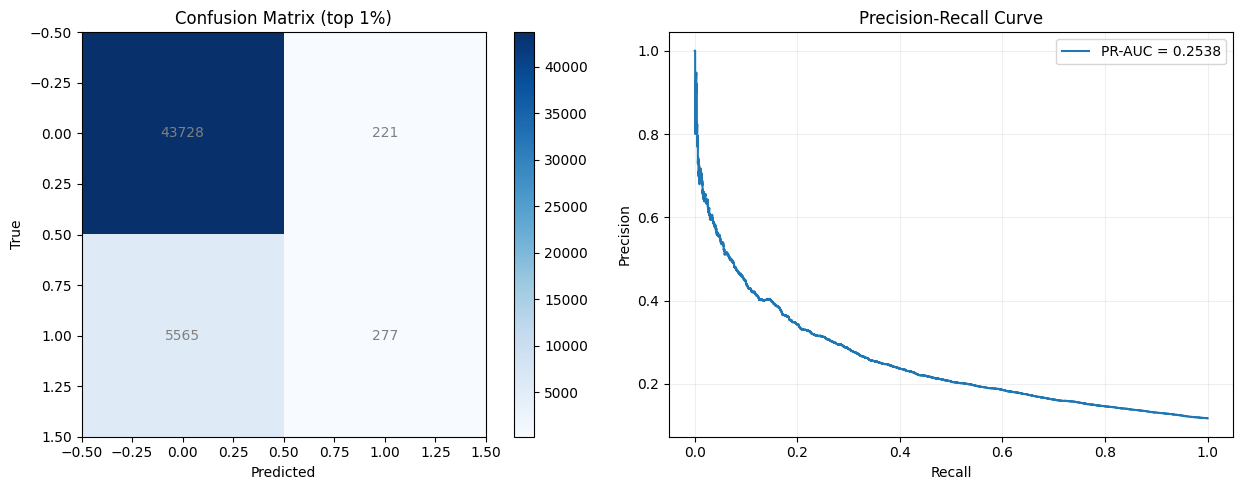

n_samples          : 49791
top_k_frac         : 0.01
threshold          : 0.8236
precision          : 0.5562
recall             : 0.0474
pr_auc             : 0.2538
P(y=1) [Baseline]  : 0.1173


In [18]:
proba = lgbm.predict_proba(X_sol)[:, 1]
evaluate_timeseries_cv_proba("GBM lightgbm entrainné sur BTC pour SOL", [y_sol], [proba], top_k=0.01)

---
### Performance sur un autre jeu de données : ETH/USDT

In [19]:
eth_df = loadCryptoCSV("ETHUSDT.csv")
X_eth, y_eth = build_dataset(eth_df, WINDOW, STRIDE, PERCENTILE)

=== Évaluation de GBM lightgbm entrainné sur BTC pour ETH ===


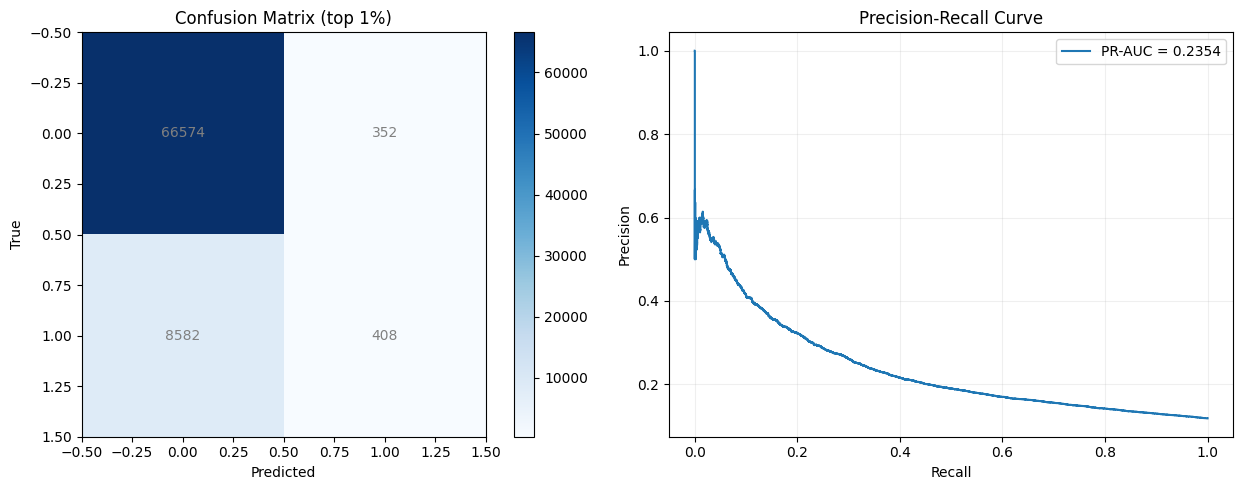

n_samples          : 75916
top_k_frac         : 0.01
threshold          : 0.8296
precision          : 0.5368
recall             : 0.0454
pr_auc             : 0.2354
P(y=1) [Baseline]  : 0.1184


In [20]:
proba = lgbm.predict_proba(X_eth)[:, 1]
evaluate_timeseries_cv_proba("GBM lightgbm entrainné sur BTC pour ETH", [y_eth], [proba], top_k=0.01)

---
### Performance sur un autre jeu de données : SUI/USDT

In [21]:
sui_df = loadCryptoCSV("SUIUSDT.csv")
X_sui, y_sui = build_dataset(sui_df, WINDOW, STRIDE, PERCENTILE)

=== Évaluation de GBM lightgbm entrainné sur BTC pour SUI ===


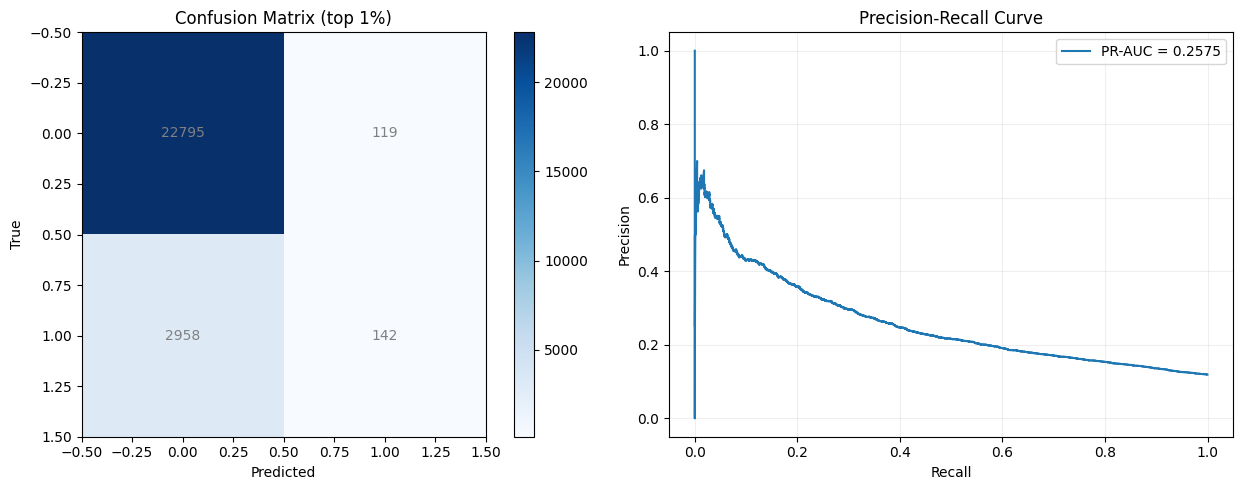

n_samples          : 26014
top_k_frac         : 0.01
threshold          : 0.8063
precision          : 0.5441
recall             : 0.0458
pr_auc             : 0.2575
P(y=1) [Baseline]  : 0.1192


In [22]:
proba = lgbm.predict_proba(X_sui)[:, 1]
evaluate_timeseries_cv_proba("GBM lightgbm entrainné sur BTC pour SUI", [y_sui], [proba], top_k=0.01)

Donc le modèle entrainné sur BTC généralise surprenament bien sur d'autres cryptomonnaies. Soit parce qu'il capture bien les patterns qui explique la volatilité ou car les autres cryptomonnaies reflètent le comportement du Bitcoin.